In [1]:
import pandas as pd
import numpy as np

from scipy.stats import ttest_ind

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sales_df = pd.read_csv(
    "../Dataset/clean_retail.csv"
)

In [3]:
sales_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


In [4]:
np.random.seed(42)

In [5]:
sales_df["AB_Group"] = np.random.choice(
    ["A","B"],
    size=len(sales_df)
)

In [6]:
sales_df["AB_Group"].value_counts()

AB_Group
A    389918
B    389507
Name: count, dtype: int64

In [7]:
sales_df.groupby(
    "AB_Group"
)["Revenue"].mean()

AB_Group
A    21.947199
B    22.636811
Name: Revenue, dtype: float64

In [8]:
group_means = (
    sales_df.groupby(
        "AB_Group"
    )["Revenue"]
    .mean()
)

group_means

AB_Group
A    21.947199
B    22.636811
Name: Revenue, dtype: float64

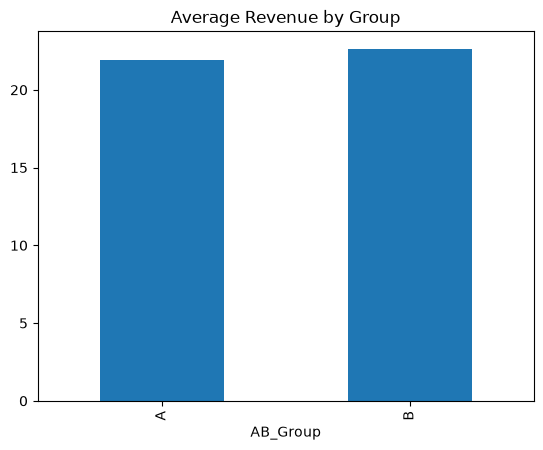

In [9]:
group_means.plot(
    kind="bar"
)

plt.title(
    "Average Revenue by Group"
)

plt.show()

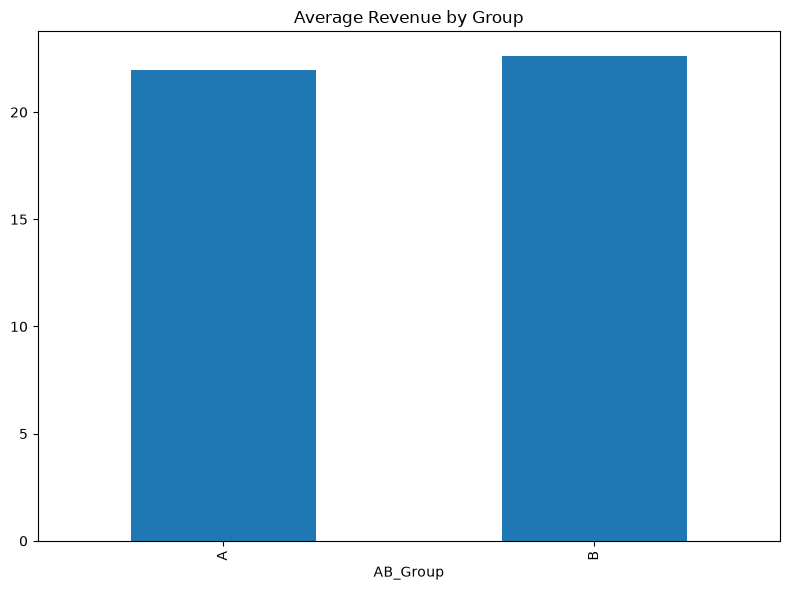

In [10]:
plt.figure(
    figsize=(8,6)
)

group_means.plot(
    kind="bar"
)

plt.title(
    "Average Revenue by Group"
)

plt.tight_layout()

plt.savefig(
    "../Images/ab_revenue_comparison.png"
)

plt.show()

In [11]:
group_a = sales_df[
    sales_df["AB_Group"]=="A"
]["Revenue"]

group_b = sales_df[
    sales_df["AB_Group"]=="B"
]["Revenue"]

In [12]:
stat,p = ttest_ind(
    group_a,
    group_b,
    equal_var=False
)

print(
    "Statistic:",
    stat
)

print(
    "P-value:",
    p
    
)

Statistic: -1.3379255602693625
P-value: 0.18092135874295664


In [13]:
lift = (
    (
        group_b.mean()
        -
        group_a.mean()
    )
    /
    group_a.mean()
) * 100

lift

np.float64(3.1421434397793826)

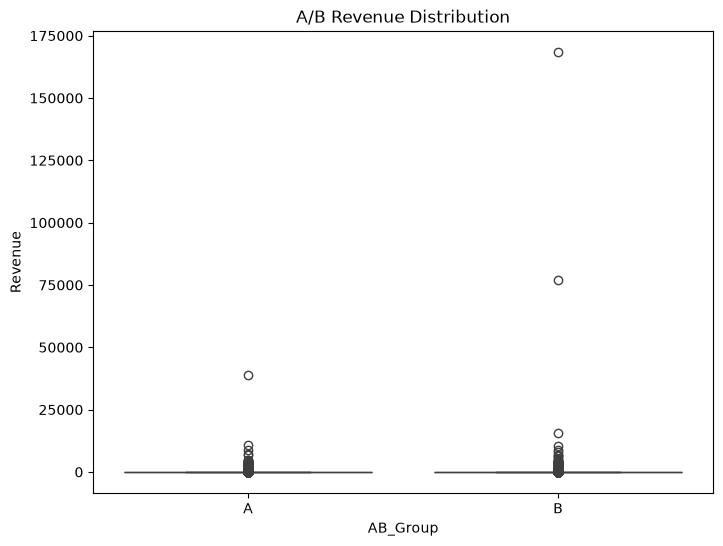

In [14]:
plt.figure(
    figsize=(8,6)
)

sns.boxplot(
    data=sales_df,
    x="AB_Group",
    y="Revenue"
)

plt.title(
    "A/B Revenue Distribution"
)

plt.show()

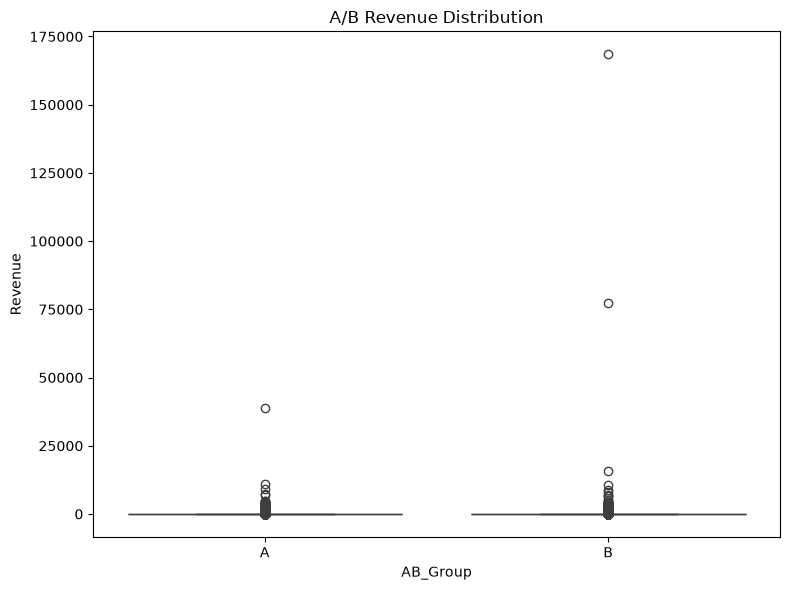

In [15]:
plt.figure(
    figsize=(8,6)
)

sns.boxplot(
    data=sales_df,
    x="AB_Group",
    y="Revenue"
)

plt.title(
    "A/B Revenue Distribution"
)

plt.tight_layout()

plt.savefig(
    "../Images/ab_boxplot.png"
)

plt.show()

In [16]:
if p < 0.05:
    print(
        "Difference is Significant"
    )
else:
    print(
        "Difference is NOT Significant"
    )

Difference is NOT Significant
